# Laboratorio 2 – Pronóstico de caudal (48 h) con **CTNet**
**Paper:** Wu, Z. & Yan, H. (2025). *A hybrid Capsule-Transformer Network for daily runoff forecasting*. Journal of Hydrology 663, 134125.

**Tarea:** a partir de 336 h (14 días) de 12 variables (caudal + 11 forzantes meteorológicos) de una cuenca, pronosticar el caudal horario (mm/h) de las 48 h siguientes.

### Contenido
1. Configuración y carga de datos (particiones `split`)
2. Exploración y verificación del orden de variables
3. Preprocesamiento (normalización, objetivo residual, índice cíclico inferido)
4. Implementación de CTNet (embedding FE+PE+CE, Transformer, Time-Capsule con Dynamic Routing, cabezas FCN)
5. Modelos base: persistencia y LSTM
6. Métricas (MAE, RMSE, NSE, CC, WI del paper + NSE por horizonte y por cuenca)
7. Entrenamiento y validación
8. Ablación (sin CE, sin cápsulas, sin Transformer, routing = 1 iteración)
9. Resultados, análisis de errores e interpretabilidad (CE y cápsulas)
10. Predicciones para `test.h5`
11. Conclusiones, limitaciones y diferencias con el paper

### Cómo ejecutar
```
# estructura esperada
Deep2/
 ├─ train-001.h5            (o train.h5)
 ├─ test.h5                 (cuando esté disponible)
 └─ lab2_ctnet/
     ├─ lab2_ctnet.ipynb    (este notebook)
     ├─ prepare_subset.py   (extracción opcional del subconjunto)
     └─ data_subset/        (se crea automáticamente)
pip install torch h5py numpy pandas matplotlib
```
Ejecutar todas las celdas. Si `data_subset/` no existe, la celda de carga lo genera desde el `.h5` leyendo por bloques (bajo uso de RAM).
Los modelos entrenados se guardan en `checkpoints/`; si existen, se cargan (poner `RETRAIN=True` para reentrenar).
Con GPU se recomienda `N_TRAIN=-1` (las 254 000 ventanas de entrenamiento) y más épocas.

In [1]:
import os, json, time, math, glob, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
try:
    import h5py
except ImportError:
    raise ImportError('Falta h5py: ejecute  %pip install h5py  y reinicie el kernel')
SMOKE = os.environ.get('LAB_SMOKE', '0') == '1'          # prueba rápida de extremo a extremo
H5_TRAIN  = next((p for p in ['../train-001.h5', '../train.h5', 'train.h5'] if os.path.exists(p)), '../train-001.h5')
H5_TEST   = next((p for p in ['test.h5', '../test.h5', '../Rainfall-Runoff/test.h5'] if os.path.exists(p)), 'test.h5')
TEST_TARGETS = next((p for p in ['test_targets.csv', '../test_targets.csv', '../Rainfall-Runoff/test_targets.csv'] if os.path.exists(p)), None)
SUBSET_DIR = 'data_subset'
N_TRAIN   = 54000        # ventanas muestreadas (−1 = todas, ~10 GB RAM). Si lo cambias, borra data_subset/
EPOCHS    = 2 if SMOKE else (20 if torch.cuda.is_available() else 8)   # con GPU: más épocas
BATCH     = 128
LR        = 1e-3
SEED      = 42
RETRAIN   = False
CKPT_DIR  = 'checkpoints_smoke' if SMOKE else 'checkpoints'
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(CKPT_DIR, exist_ok=True); os.makedirs('figs', exist_ok=True)
torch.manual_seed(SEED); np.random.seed(SEED)
if DEVICE == 'cpu': torch.set_num_threads(os.cpu_count())
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
print('device:', DEVICE, '| torch', torch.__version__, '| smoke:', SMOKE, '| test:', H5_TEST, os.path.exists(H5_TEST), '| targets:', TEST_TARGETS)

device: cuda | torch 2.14.0+cu130 | smoke: False | test: test.h5 True | targets: test_targets.csv


## 1. Carga de datos y particiones
`train.h5` contiene `X [N,336,12]`, `y [N,48]`, `y_aux [N,48,11]`, `basin_id`, `split` (0 = entrenamiento, 1 = validación).
El archivo pesa ~5 GB, por lo que se extrae un **subconjunto aleatorio reproducible** de ventanas de entrenamiento (todas las cuencas quedan representadas)
y **toda** la partición de validación. La lectura es secuencial por bloques; la presión se pasa a kPa para almacenar `X` en float16 sin desbordes.

In [2]:
PRES = 4   # índice de la presión en X (ver verificación de orden más abajo)

def extract_subset(h5_path, out_dir, n_train=54000, part=9000, seed=42):
    import h5py
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)
    with h5py.File(h5_path, 'r') as f:
        split, basin = f['split'][:], f['basin_id'][:]
        tr, va = np.where(split == 0)[0], np.where(split == 1)[0]
        if n_train > 0: tr = np.sort(rng.choice(tr, n_train, replace=False))
        for name, idx in [('train', tr), ('val', va)]:
            for p, s in enumerate(range(0, len(idx), part)):
                sub = idx[s:s + part]; Xs, ys, yas = [], [], []
                for b0 in range(sub[0], sub[-1] + 1, 4000):
                    m = sub[(sub >= b0) & (sub < b0 + 4000)]
                    if len(m) == 0: continue
                    b1 = m[-1] + 1
                    Xs.append(f['X'][b0:b1][m - b0]); ys.append(f['y'][b0:b1][m - b0]); yas.append(f['y_aux'][b0:b1][m - b0])
                X = np.concatenate(Xs); X[..., PRES] /= 1000.
                YA = np.concatenate(yas); YA[..., PRES] /= 1000.
                np.savez(f'{out_dir}/{name}_{p}.npz', X=X.astype(np.float16), y=np.concatenate(ys),
                         y_aux=YA.astype(np.float16), basin=basin[sub], idx=sub)

def load_parts(name):
    fs = sorted(glob.glob(f'{SUBSET_DIR}/{name}_*.npz'), key=lambda s: int(s.split('_')[-1][:-4]))
    ds = [np.load(f) for f in fs]
    return {k: np.concatenate([d[k] for d in ds]) for k in ['X', 'y', 'y_aux', 'basin']}

if not glob.glob(f'{SUBSET_DIR}/train_*.npz'):
    extract_subset(H5_TRAIN, SUBSET_DIR, N_TRAIN, seed=SEED)
tr, va = load_parts('train'), load_parts('val')
if SMOKE:
    tr = {k: v[:3000] for k, v in tr.items()}; va = {k: v[:1500] for k, v in va.items()}
print('train:', tr['X'].shape, tr['y'].shape, '| val:', va['X'].shape, va['y'].shape)
print('cuencas train:', len(np.unique(tr['basin'])), '| cuencas val:', len(np.unique(va['basin'])),
      '| val ⊂ train:', set(np.unique(va['basin'])) <= set(np.unique(tr['basin'])))

train: (54000, 336, 12) (54000, 48) | val: (18142, 336, 12) (18142, 48)
cuencas train: 508 | cuencas val: 508 | val ⊂ train: True


## 2. Exploración y verificación del orden de las variables
El enunciado lista las variables en un orden distinto y `metadata.json` no venía con el archivo de entrenamiento. Comparando rangos físicos y la **continuidad** entre la última hora de
cada columna de `X` y la primera hora de `y`, se identificó que las columnas están en **orden alfabético (nombres NLDAS/CAMELS)** con el caudal al final:

> **Confirmación posterior:** el `metadata.json` publicado junto a `test.h5` (carpeta `Rainfall-Runoff/`) indica `target_channel = 11` (`specific_discharge`) y los canales 0–10 exactamente en el orden alfabético que dedujimos.

In [3]:
VARS = ['convective_fraction', 'longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure_kPa',
        'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v', 'qobs_mm_h']
FLOW, SW, PRCP = 11, 5, 8
Xs = tr['X'][:5000].astype(np.float32)
desc = pd.DataFrame({'var': VARS, 'min': Xs.min((0, 1)), 'media': Xs.mean((0, 1)), 'max': Xs.max((0, 1)),
                     'corr(X[-1,c], y[0])': [np.corrcoef(Xs[:, -1, c], tr['y'][:5000, 0])[0, 1] for c in range(12)]})
display(desc.round(4))
q = np.concatenate([tr['y'].ravel(), tr['X'][..., FLOW].astype(np.float32).ravel()[::50]])
print('caudal (mm/h): mediana %.4f | p90 %.4f | p99 %.4f | max %.3f' % tuple(np.percentile(q, [50, 90, 99]).tolist() + [q.max()]))

,var,min,media,max,"corr(X[-1,c], y[0])"
0,convective_fraction,0.0000,0.060000,1.0000,0.0537
1,longwave_radiation,105.4375,312.448303,523.5000,-0.0963
2,potential_energy,0.0000,200.294800,5652.0000,-0.0945
3,potential_evaporation,-0.4802,0.205900,1.5352,-0.1322
4,pressure_kPa,65.8750,93.302299,104.1875,-0.0413
5,shortwave_radiation,0.0000,200.873901,1216.0000,-0.0010
6,specific_humidity,0.0001,0.007600,0.0260,-0.0928
7,temperature,-27.6562,13.125300,47.0625,-0.1943
8,total_precipitation,0.0000,0.129900,76.6250,0.1606
9,wind_u,-21.0312,1.018900,17.0625,0.0952


caudal (mm/h): mediana 0.0207 | p90 0.1609 | p99 0.6714 | max 18.743


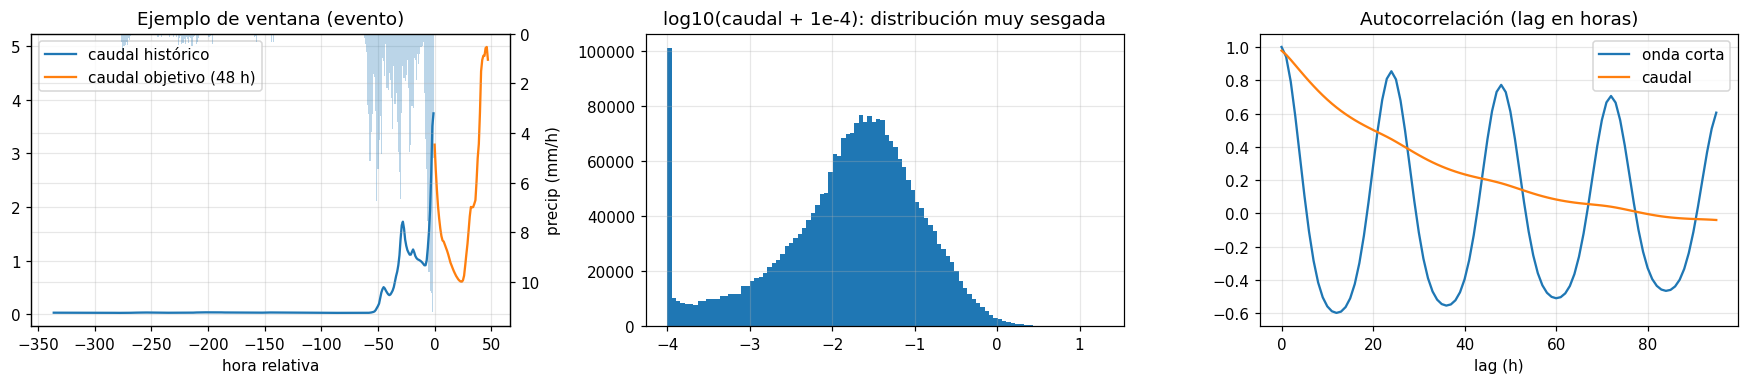

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
i = int(np.argmax(tr['y'][:2000].max(1)))
t_in, t_out = np.arange(-336, 0), np.arange(0, 48)
ax[0].plot(t_in, tr['X'][i, :, FLOW], label='caudal histórico'); ax[0].plot(t_out, tr['y'][i], label='caudal objetivo (48 h)')
a2 = ax[0].twinx(); a2.bar(t_in, tr['X'][i, :, PRCP], color='tab:blue', alpha=.3, width=1); a2.invert_yaxis(); a2.set_ylabel('precip (mm/h)')
ax[0].set_title('Ejemplo de ventana (evento)'); ax[0].legend(loc='upper left'); ax[0].set_xlabel('hora relativa')
ax[1].hist(np.log10(tr['y'].ravel() + 1e-4), 100); ax[1].set_title('log10(caudal + 1e-4): distribución muy sesgada')
# ACF de la radiación de onda corta y del caudal dentro de las ventanas -> ciclo de 24 h
def acf(x, L=96):
    x = x - x.mean(1, keepdims=True); d = (x * x).sum(1)
    return np.array([np.nanmean((x[:, :x.shape[1] - k] * x[:, k:]).sum(1) / (d + 1e-12)) for k in range(L)])
ax[2].plot(acf(tr['X'][:3000, :, SW].astype(np.float32)), label='onda corta'); ax[2].plot(acf(tr['X'][:3000, :, FLOW].astype(np.float32)), label='caudal')
ax[2].set_title('Autocorrelación (lag en horas)'); ax[2].legend(); ax[2].set_xlabel('lag (h)')
plt.tight_layout(); plt.savefig('figs/eda.png'); plt.show()

## 3. Preprocesamiento

| Decisión | Detalle | Justificación |
|---|---|---|
| Normalización | z-score por variable con estadísticas del *train* | escalas muy distintas (Pa, W/m², mm/h) |
| Objetivo residual | la red predice $\Delta = (y_{t+h} - q_t)/\sigma_q$ y $\hat y = q_t + \sigma_q\,\Delta$ | el caudal horario es muy persistente; la salida cero equivale al modelo de persistencia, la red aprende la *corrección*. Es una adaptación nuestra (no está en el paper), por eso se ablaciona en la sección 9 |
| Pérdida | L1 (MAE) sobre el objetivo normalizado, como el paper (Ec. 25) | robusta a la cola pesada del caudal |
| Índice cíclico `idx` | **fase diaria inferida** de la radiación de onda corta | el dataset no trae fechas (ver abajo) |
| Salida | clip $\hat y \ge 0$ en evaluación | el caudal es no negativo |

**Cyclic Embedding sin fechas.** En el paper, $E_{cyc}=W_{cyc}[(idx \oplus \text{range}(t)) \bmod D]$ con `idx` = día del año del inicio de la secuencia y $D=365$.
Nuestro dataset es horario y **no incluye marcas de tiempo**, por lo que no se conoce el día del año. En cambio, la radiación de onda corta tiene un ciclo diario
perfecto: estimamos la fase del primer armónico de 24 h, $\phi=\arg\sum_t SW_t e^{-2\pi i t/24}$, cuyo máximo corresponde al **mediodía solar**.
Así definimos `idx` = hora solar local de la primera hora de la ventana y usamos **$D = 24$** (el paper también evalúa $D=24$ en la Tabla 12).
Esto preserva la idea central del CE: una tabla aprendible indexada por la posición *dentro del ciclo* (no por la posición en la secuencia, que ya cubre el PE).

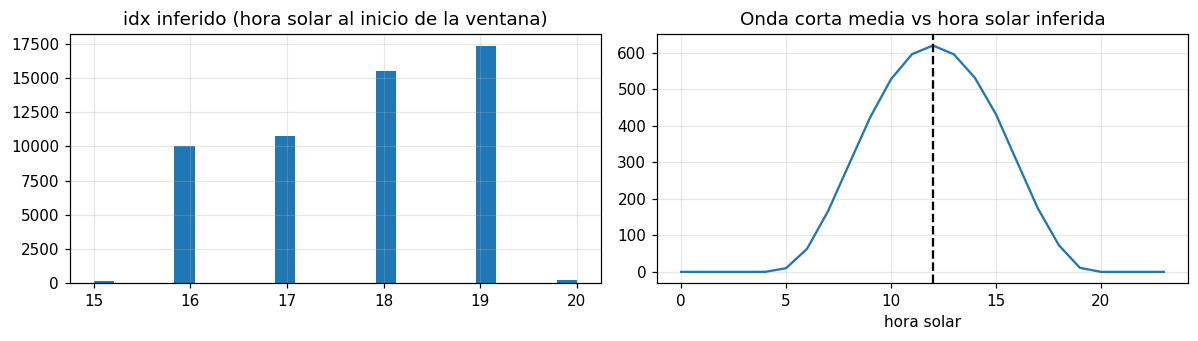

In [5]:
def solar_phase_idx(X):
    # hora solar local (0..23) de la primera hora de la ventana, estimada con el primer armónico de 24 h de la onda corta
    sw = X[:, :, SW].astype(np.float32)
    t = np.arange(sw.shape[1])
    z = (sw * np.exp(-2j * np.pi * t / 24)).sum(1)
    t_peak = (-np.angle(z) / (2 * np.pi) * 24) % 24          # hora (dentro de la ventana, mod 24) del máximo de radiación
    return np.round(12 - t_peak).astype(int) % 24

tr['idx'], va['idx'] = solar_phase_idx(tr['X']), solar_phase_idx(va['X'])
# comprobación: perfil medio de onda corta alineado con la hora solar inferida
sw_al = np.stack([np.roll(tr['X'][i, :48, SW].astype(np.float32), tr['idx'][i])[:24] for i in range(2000)])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(tr['idx'], bins=24); ax[0].set_title('idx inferido (hora solar al inicio de la ventana)')
ax[1].plot(sw_al.mean(0)); ax[1].axvline(12, c='k', ls='--'); ax[1].set_title('Onda corta media vs hora solar inferida'); ax[1].set_xlabel('hora solar')
plt.tight_layout(); plt.savefig('figs/phase.png'); plt.show()

In [6]:
Xtr32 = tr['X'].astype(np.float32)
MU = Xtr32.reshape(-1, 12).mean(0, dtype=np.float64).astype(np.float32)
SD = Xtr32.reshape(-1, 12).std(0, dtype=np.float64).astype(np.float32) + 1e-6
SIG_Q = float(SD[FLOW]); del Xtr32
print('sigma_q = %.4f mm/h' % SIG_Q)

def to_tensors(d):
    X = torch.from_numpy(((d['X'].astype(np.float32) - MU) / SD))
    qlast = torch.from_numpy(d['X'][:, -1, FLOW].astype(np.float32))
    y = torch.from_numpy(d['y'].astype(np.float32))
    return dict(X=X, idx=torch.from_numpy(d['idx']).long(), qlast=qlast, y=y, ynorm=(y - qlast[:, None]) / SIG_Q)
Ttr, Tva = to_tensors(tr), to_tensors(va)
def batches(T, bs, shuffle):
    n = len(T['y']); order = torch.randperm(n) if shuffle else torch.arange(n)
    for s in range(0, n, bs):
        b = order[s:s + bs]; yield {k: v[b] for k, v in T.items()}

sigma_q = 0.1590 mm/h


## 4. Implementación de CTNet (desde cero, PyTorch)
Arquitectura (Fig. 1 del paper) adaptada a 336 pasos horarios × 12 variables → 48 horizontes:

* **Embedding** (Ec. 1–4): $E=\text{Dropout}(W_{fea}X+b + PE_{pos} + W_{cyc}[(idx+\text{range}(t)) \bmod 24])$, $d_{model}=32$.
* **Transformer layer** (Ec. 5–11): 2 bloques *post-LN*, 4 cabezas, FFN de 128, dropout 0.2. Salida $O_h\in\mathbb R^{336\times32}$.
* **Time Capsule layer** (Ec. 12–20): dos Conv1D (k=3) + ReLU; una Conv1D con kernel = stride = 24 h genera, para cada uno de los 14 días, 8 cápsulas primarias de dimensión 8 (112 cápsulas bajas, *squash*).
  **Dynamic Routing** de 3 iteraciones hacia **12 cápsulas altas de dimensión 30** (igual que el paper) con matrices $W_{ij}$ propias por par.
* **Prediction layer** (Ec. 21–24): $\hat y = FCN_c(\text{Flatten}(O_c)) + FCN_h(O_h)$, cada FCN con salida de 48 valores.
  Para $FCN_h$ se usa $[O_h^{(t)};\ \overline{O_h}]$ (último token y media temporal), ya que el paper predice un solo paso y no especifica cómo reducir $O_h$.

El modelo completo tiene ~482 k parámetros (el paper reporta 482 874).

In [7]:
import math, torch, torch.nn as nn, torch.nn.functional as F

def squash(s, dim=-1, eps=1e-8):
    """Ec. (15): squash(x) = |x|^2/(1+|x|^2) * x/|x|"""
    n2 = (s ** 2).sum(dim=dim, keepdim=True)
    return n2 / (1.0 + n2) * s / torch.sqrt(n2 + eps)

class EmbeddingLayer(nn.Module):
    """FE (Ec.1) + PE aprendible (Ec.2) + Cyclic Embedding (Ec.3) + Dropout (Ec.4)."""
    def __init__(self, n_feat, d_model, seq_len, cycle_len=24, use_ce=True, p=0.2):
        super().__init__()
        self.fe = nn.Linear(n_feat, d_model)                    # W_fea X + b_fea
        self.pe = nn.Parameter(torch.zeros(seq_len, d_model))   # PE(pos) aprendible
        nn.init.normal_(self.pe, std=0.02)
        self.use_ce, self.D = use_ce, cycle_len
        if use_ce:
            self.cyc = nn.Embedding(cycle_len, d_model)         # W_cyc ∈ R^{D×d}
            nn.init.normal_(self.cyc.weight, std=0.02)
        self.register_buffer('rng', torch.arange(seq_len), persistent=False)
        self.drop = nn.Dropout(p)
    def forward(self, x, idx):
        e = self.fe(x) + self.pe.unsqueeze(0)
        if self.use_ce:  # E_cyc = W_cyc[(idx ⊕ range(t)) mod D]
            e = e + self.cyc((idx.unsqueeze(1) + self.rng.unsqueeze(0)) % self.D)
        return self.drop(e)

class TransformerBlock(nn.Module):
    """Post-LN como en Ec.(5)-(6): X1 = Drop(LN(X + MHA(X))), X = Drop(LN(X1 + FFN(X1)))."""
    def __init__(self, d_model, n_heads, d_ff, p=0.2):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)   # W^Q, W^K, W^V
        self.wo = nn.Linear(d_model, d_model)        # W^O
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))  # Ec.(11)
        self.drop = nn.Dropout(p); self.explicit = False
    def mha(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        if self.explicit:   # Ec.(8) explícita (para inspeccionar pesos de atención)
            att = torch.softmax(q @ k.transpose(-1, -2) / math.sqrt(self.dh), dim=-1)
            self.last_attn = att.detach(); o = att @ v
        else:               # misma operación, kernel fusionado (≈3× más rápido en CPU)
            o = F.scaled_dot_product_attention(q, k, v)
        o = o.transpose(1, 2).reshape(B, T, D)                                     # Concat(heads)
        return self.wo(o)                                                           # Ec.(9)
    def forward(self, x):
        x1 = self.drop(self.ln1(x + self.mha(x)))
        return self.drop(self.ln2(x1 + self.ffn(x1)))

class PrimaryCapsules(nn.Module):
    """Ec.(12)-(14): F = ReLU(Conv1D(ReLU(Conv1D(E)))), U = squash(Conv1D(F)).
    La última Conv1D usa kernel=stride=patch (24 h) -> cada cápsula primaria cubre una
    región local (un día) de la ventana; n_types cápsulas de dim d_prim por región."""
    def __init__(self, d_model, hidden=32, n_types=8, d_prim=8, patch=24):
        super().__init__()
        self.c1 = nn.Conv1d(d_model, hidden, 3, padding=1)
        self.c2 = nn.Conv1d(hidden, hidden, 3, padding=1)
        self.cp = nn.Conv1d(hidden, n_types * d_prim, patch, stride=patch)
        self.n_types, self.d_prim = n_types, d_prim
    def forward(self, e):                      # e: [B,T,d]
        f = F.relu(self.c2(F.relu(self.c1(e.transpose(1, 2)))))
        u = self.cp(f)                         # [B, n_types*d_prim, T/patch]
        B, _, P = u.shape
        u = u.view(B, self.n_types, self.d_prim, P).permute(0, 3, 1, 2).reshape(B, P * self.n_types, self.d_prim)
        return squash(u)                       # [B, N_in, d_prim]

class DynamicRouting(nn.Module):
    """Algoritmo 1 / Ec.(16)-(20). W_ij propio para cada par (cápsula baja i, alta j)."""
    def __init__(self, n_in, d_in, n_out=12, d_out=30, n_iter=3):
        super().__init__()
        self.W = nn.Parameter(0.05 * torch.randn(n_in, n_out, d_out, d_in))
        self.n_iter, self.n_out = n_iter, n_out
    def forward(self, u):                                   # u: [B, N_in, d_in]
        u_hat = torch.einsum('ijkl,bil->bijk', self.W, u)   # u_{j|i} = W_ij u_i  [B,N_in,N_out,d_out]
        b = torch.zeros(u.shape[0], u.shape[1], self.n_out, device=u.device)
        u_hat_d = u_hat.detach()
        for r in range(self.n_iter):
            c = torch.softmax(b, dim=2)                      # c_ij = softmax_j(b_ij)
            uh = u_hat if r == self.n_iter - 1 else u_hat_d  # gradiente solo en la última iteración
            v = squash((c.unsqueeze(-1) * uh).sum(1))        # s_j = Σ_i c_ij u_{j|i};  v_j = squash(s_j)
            if r < self.n_iter - 1:
                b = b + (u_hat_d * v.unsqueeze(1)).sum(-1)   # b_ij += u_{j|i}·v_j
        self.last_c = c.detach()
        return v                                            # O_c: [B, N_out, d_out]

def fcn(d_in, d_hidden, d_out, p=0.0):
    """Ec.(21): FCN(x) = W2 ReLU(W1 x + b1) + b2"""
    return nn.Sequential(nn.Linear(d_in, d_hidden), nn.ReLU(), nn.Dropout(p), nn.Linear(d_hidden, d_out))

class CTNet(nn.Module):
    """Capsule-Transformer Network adaptado a pronóstico multi-horizonte (48 h).
    use_transformer / use_capsule / use_ce permiten las ablaciones."""
    def __init__(self, n_feat=12, seq_len=336, horizon=48, d_model=32, n_heads=4, d_ff=128,
                 n_layers=2, n_caps=12, d_caps=30, n_iter=3, n_types=8, d_prim=8, patch=24,
                 cycle_len=24, use_ce=True, use_transformer=True, use_capsule=True, p=0.2):
        super().__init__()
        self.emb = EmbeddingLayer(n_feat, d_model, seq_len, cycle_len, use_ce, p)
        self.use_tr, self.use_cap = use_transformer, use_capsule
        if use_transformer:
            self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, p) for _ in range(n_layers)])
            # O_h -> [último token ; media temporal] -> FCN_h -> 48 horizontes
            self.fcn_h = fcn(2 * d_model, 128, horizon, p)
        if use_capsule:
            self.prim = PrimaryCapsules(d_model, 32, n_types, d_prim, patch)
            self.route = DynamicRouting((seq_len // patch) * n_types, d_prim, n_caps, d_caps, n_iter)
            self.fcn_c = fcn(n_caps * d_caps, 128, horizon, p)   # FCN_c(Flatten(O_c))
    def forward(self, x, idx):
        e = self.emb(x, idx)
        y = 0.0
        if self.use_tr:
            h = e
            for blk in self.blocks: h = blk(h)
            y = y + self.fcn_h(torch.cat([h[:, -1], h.mean(1)], -1))      # ŷ_transformer
        if self.use_cap:
            oc = self.route(self.prim(e))
            y = y + self.fcn_c(oc.flatten(1))                               # ŷ_capsule
        return y                                                            # ŷ = ŷ_c + ŷ_t (Ec.24)

class LSTMBaseline(nn.Module):
    def __init__(self, n_feat=12, hidden=128, horizon=48, p=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.drop = nn.Dropout(p); self.head = nn.Linear(hidden, horizon)
    def forward(self, x, idx=None):
        o, _ = self.lstm(x)
        return self.head(self.drop(o[:, -1]))

In [8]:
m = CTNet()
print('Parámetros CTNet:', sum(p.numel() for p in m.parameters()))
for n, mod in [('embedding', m.emb), ('transformer', m.blocks), ('fcn_h', m.fcn_h), ('primary caps', m.prim), ('routing', m.route), ('fcn_c', m.fcn_c)]:
    print(f'  {n:13s}', sum(p.numel() for p in mod.parameters()))
with torch.no_grad():
    print('salida:', m(Ttr['X'][:4], Ttr['idx'][:4]).shape)

Parámetros CTNet: 482240
  embedding     11936
  transformer   25408
  fcn_h         14512
  primary caps  55424
  routing       322560
  fcn_c         52400
salida: torch.Size([4, 48])


## 5. Métricas
Las 5 métricas del paper (Ec. 30–34) calculadas en **mm/h** sobre todos los pares (muestra, horizonte) de validación, más:
NSE por horizonte (1…48 h), **NSE mediano por cuenca** (estándar en hidrología de gran muestra) y métricas de **picos** (ventanas cuyo caudal futuro supera el p99).

In [9]:
def metrics(y, p):
    y, p = y.ravel().astype(np.float64), p.ravel().astype(np.float64)
    e = y - p; ym, pm = y.mean(), p.mean()
    return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e ** 2).mean()),
                NSE=1 - (e ** 2).sum() / ((y - ym) ** 2).sum(),
                CC=np.corrcoef(y, p)[0, 1],
                WI=1 - (e ** 2).sum() / ((np.abs(p - ym) + np.abs(y - ym)) ** 2).sum())
def nse_per_horizon(y, p): return 1 - ((y - p) ** 2).sum(0) / ((y - y.mean(0)) ** 2).sum(0)
def basin_nse(y, p, basins):
    out = {}
    for b in np.unique(basins):
        m = basins == b; yy, pp = y[m].ravel(), p[m].ravel()
        den = ((yy - yy.mean()) ** 2).sum()
        if den > 0: out[b] = 1 - ((yy - pp) ** 2).sum() / den
    return pd.Series(out)
def full_report(y, p, basins):
    r = metrics(y, p); bn = basin_nse(y, p, basins)
    r['NSE_cuenca_mediana'] = bn.median()
    thr = np.percentile(y.max(1), 99); m = y.max(1) >= thr
    r['MAE_picos(p99)'] = np.abs(y[m] - p[m]).mean()
    r['err_rel_pico_%'] = 100 * np.median((p[m].max(1) - y[m].max(1)) / y[m].max(1))
    r['NSE_h1'], r['NSE_h24'], r['NSE_h48'] = nse_per_horizon(y, p)[[0, 23, 47]]
    return r

## 6. Entrenamiento y validación
Adam (β = 0.9, 0.999) como en el paper, con *OneCycle* (lr máx 1e-3; el paper usa 1e-4 durante 300 épocas, inviable aquí), batch 128, *gradient clipping* 1.0,
pérdida L1. Se guarda el estado con **mejor NSE de validación** (early stopping). Todos los modelos usan la misma semilla, datos y presupuesto de épocas.

In [10]:
@torch.no_grad()
def predict(model, T, bs=512):
    model.eval(); out = []
    for b in batches(T, bs, False):
        d = model(b['X'].to(DEVICE), b['idx'].to(DEVICE)).cpu()
        base = b['qlast'][:, None] if getattr(model, 'residual', True) else 0.0   # residual: ŷ = q_t + σ·Δ ; directo: ŷ = σ·out
        out.append((base + SIG_Q * d).clamp_min(0))
    return torch.cat(out).numpy()

def train_model(name, make, epochs=EPOCHS, lr=LR, residual=True):
    path = f'{CKPT_DIR}/{name}.pt'
    model = make().to(DEVICE)
    if os.path.exists(path) and not RETRAIN:
        model.residual = residual
        ck = torch.load(path, map_location=DEVICE, weights_only=False); model.load_state_dict(ck['state'])
        print(f'[{name}] cargado desde checkpoint'); return model, ck['hist']
    torch.manual_seed(SEED)
    model = make().to(DEVICE); model.residual = residual
    opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    steps = epochs * math.ceil(len(Ttr['y']) / BATCH)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.15)
    hist, best, best_state = [], -1e9, None
    for ep in range(epochs):
        model.train(); t0 = time.time(); tl = []
        for b in batches(Ttr, BATCH, True):
            out = model(b['X'].to(DEVICE), b['idx'].to(DEVICE))
            target = b['ynorm'] if residual else b['y'] / SIG_Q             # residual (Δ) o caudal directo
            loss = (out - target.to(DEVICE)).abs().mean()                   # L1 (Ec. 25)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sch.step()
            tl.append(loss.item())
        pv = predict(model, Tva); mv = metrics(va['y'], pv)
        hist.append(dict(epoch=ep + 1, train_L1=np.mean(tl), val_MAE=mv['MAE'], val_NSE=mv['NSE'], sec=time.time() - t0))
        print(f"[{name}] ep {ep+1:2d} | train L1 {np.mean(tl):.4f} | val MAE {mv['MAE']:.4f} NSE {mv['NSE']:.4f} | {time.time()-t0:.0f}s", flush=True)
        if mv['NSE'] > best:
            best = mv['NSE']; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    torch.save({'state': best_state, 'hist': hist}, path)
    return model, hist

## 7. Modelos base
1. **Persistencia**: $\hat y_{t+h}=q_t$ para los 48 horizontes (referencia mínima; muy exigente en horizontes cortos).
2. **LSTM** (el baseline principal del paper): 1 capa, 64 unidades, último estado → Linear(48); mismas entradas, mismo objetivo residual, pérdida y presupuesto.

In [11]:
P = {}                                   # predicciones de validación por modelo
P['Persistencia'] = np.repeat(va['X'][:, -1, FLOW].astype(np.float32)[:, None], 48, 1)
lstm, h_lstm = train_model('lstm', lambda: LSTMBaseline(hidden=64))
P['LSTM'] = predict(lstm, Tva)

[lstm] cargado desde checkpoint


## 8. Entrenamiento de CTNet (modelo completo)

In [12]:
ctnet, h_ct = train_model('ctnet', lambda: CTNet())
P['CTNet'] = predict(ctnet, Tva)
pd.DataFrame(h_ct)

[ctnet] cargado desde checkpoint


,epoch,train_L1,val_MAE,val_NSE,sec
0,1,0.188424,0.022762,0.364740,34.387612
1,2,0.122434,0.019916,0.463241,33.766951
2,3,0.115213,0.019699,0.494134,33.538641
3,4,0.111830,0.019350,0.526887,33.140563
4,5,0.110456,0.019192,0.528910,33.651577
5,6,0.108610,0.019199,0.536126,33.495152
6,7,0.107543,0.018812,0.547734,33.261060
7,8,0.106162,0.018632,0.561240,33.523689
8,9,0.104607,0.018632,0.558655,33.637650
9,10,0.102870,0.018980,0.556806,33.497984


## 9. Estudio de ablación
Siguiendo la Tabla 7 del paper (w/o CE, w/o capsule) y ampliándola:

| Variante | Qué se quita | Pregunta |
|---|---|---|
| CTNet w/o CE | Cyclic Embedding | ¿aporta la fase diaria (hora solar) explícita? |
| CTNet w/o capsule | Time Capsule layer (queda Transformer + CE) | ¿aporta la rama local de cápsulas? |
| CTNet w/o Transformer | Rama de atención (queda Capsule + CE) | ¿aporta la dependencia global? |
| CTNet routing = 1 | Dynamic Routing (1 iteración = acoplamientos uniformes) | ¿importa el *routing-by-agreement*? |
| CTNet sin residual | Objetivo residual (la red predice el caudal $y/\sigma_q$ directamente, como en el paper) | ¿cuánto del resultado se debe a nuestra adaptación y no a CTNet? |

> Con GPU, la única variante que se entrena en una ejecución normal es *CTNet sin residual* (~11 min); el resto se carga desde `checkpoints/`.

In [13]:
ABL = {'CTNet w/o CE': lambda: CTNet(use_ce=False),
       'CTNet w/o capsule': lambda: CTNet(use_capsule=False),
       'CTNet w/o Transformer': lambda: CTNet(use_transformer=False),
       'CTNet routing=1': lambda: CTNet(n_iter=1)}
H = {'LSTM': h_lstm, 'CTNet': h_ct}; MODELS = {'LSTM': lstm, 'CTNet': ctnet}
for n, mk in ABL.items():
    fname = n.replace(' ', '_').replace('/', '').replace('=', '')
    MODELS[n], H[n] = train_model(fname, mk)
    P[n] = predict(MODELS[n], Tva)
# Ablación de nuestra adaptación: objetivo directo (sin conexión residual de persistencia)
MODELS['CTNet sin residual'], H['CTNet sin residual'] = train_model('CTNet_sin_residual', lambda: CTNet(), residual=False)
P['CTNet sin residual'] = predict(MODELS['CTNet sin residual'], Tva)

[CTNet_wo_CE] cargado desde checkpoint
[CTNet_wo_capsule] cargado desde checkpoint
[CTNet_wo_Transformer] cargado desde checkpoint
[CTNet_routing1] cargado desde checkpoint
[CTNet_sin_residual] ep  1 | train L1 0.3149 | val MAE 0.0260 NSE 0.4425 | 33s
[CTNet_sin_residual] ep  2 | train L1 0.1471 | val MAE 0.0227 NSE 0.5495 | 32s
[CTNet_sin_residual] ep  3 | train L1 0.1360 | val MAE 0.0212 NSE 0.5654 | 32s
[CTNet_sin_residual] ep  4 | train L1 0.1291 | val MAE 0.0201 NSE 0.5902 | 33s
[CTNet_sin_residual] ep  5 | train L1 0.1254 | val MAE 0.0198 NSE 0.5765 | 33s
[CTNet_sin_residual] ep  6 | train L1 0.1234 | val MAE 0.0213 NSE 0.6012 | 33s
[CTNet_sin_residual] ep  7 | train L1 0.1207 | val MAE 0.0194 NSE 0.6029 | 33s
[CTNet_sin_residual] ep  8 | train L1 0.1197 | val MAE 0.0197 NSE 0.6158 | 33s
[CTNet_sin_residual] ep  9 | train L1 0.1180 | val MAE 0.0205 NSE 0.6047 | 33s
[CTNet_sin_residual] ep 10 | train L1 0.1164 | val MAE 0.0197 NSE 0.6071 | 33s
[CTNet_sin_residual] ep 11 | train L1

## 10. Resultados en validación
> La validación se usó también para elegir la mejor época (*early stopping*), por lo que estas métricas son ligeramente optimistas. **Los resultados de referencia son los de test (sección 13).**

In [14]:
res = pd.DataFrame({k: full_report(va['y'], v, va['basin']) for k, v in P.items()}).T
res['Parámetros'] = [sum(p.numel() for p in MODELS[k].parameters()) if k in MODELS else 0 for k in res.index]
res.to_csv('figs/resultados_validacion.csv')
display(res.round(4))

,MAE,RMSE,NSE,CC,WI,NSE_cuenca_mediana,MAE_picos(p99),err_rel_pico_%,NSE_h1,NSE_h24,NSE_h48,Parámetros
Persistencia,0.0245,0.1379,0.3545,0.6936,0.8194,0.5249,0.7646,-72.3830,0.9652,0.2287,0.0417,0
LSTM,0.0183,0.1120,0.5738,0.7595,0.8483,0.6648,0.5776,-66.8731,0.9666,0.4912,0.3871,23088
CTNet,0.0183,0.1106,0.5847,0.7678,0.8450,0.6537,0.5696,-68.4987,0.9655,0.5101,0.3958,482240
CTNet w/o CE,0.0179,0.1096,0.5919,0.7730,0.8472,0.6678,0.5586,-68.4183,0.9661,0.5179,0.3980,481472
CTNet w/o capsule,0.0182,0.1131,0.5659,0.7542,0.8422,0.6581,0.6009,-73.0659,0.9651,0.4888,0.3947,51856
CTNet w/o Transformer,0.0187,0.1111,0.5812,0.7645,0.8457,0.6582,0.5717,-67.1499,0.9660,0.5043,0.3842,442320
CTNet routing=1,0.0188,0.1111,0.5811,0.7643,0.8468,0.6580,0.5763,-68.5834,0.9655,0.5043,0.3922,482240
CTNet sin residual,0.0196,0.1050,0.6259,0.7940,0.8630,0.6469,0.5101,-64.2066,0.8843,0.5681,0.4664,482240


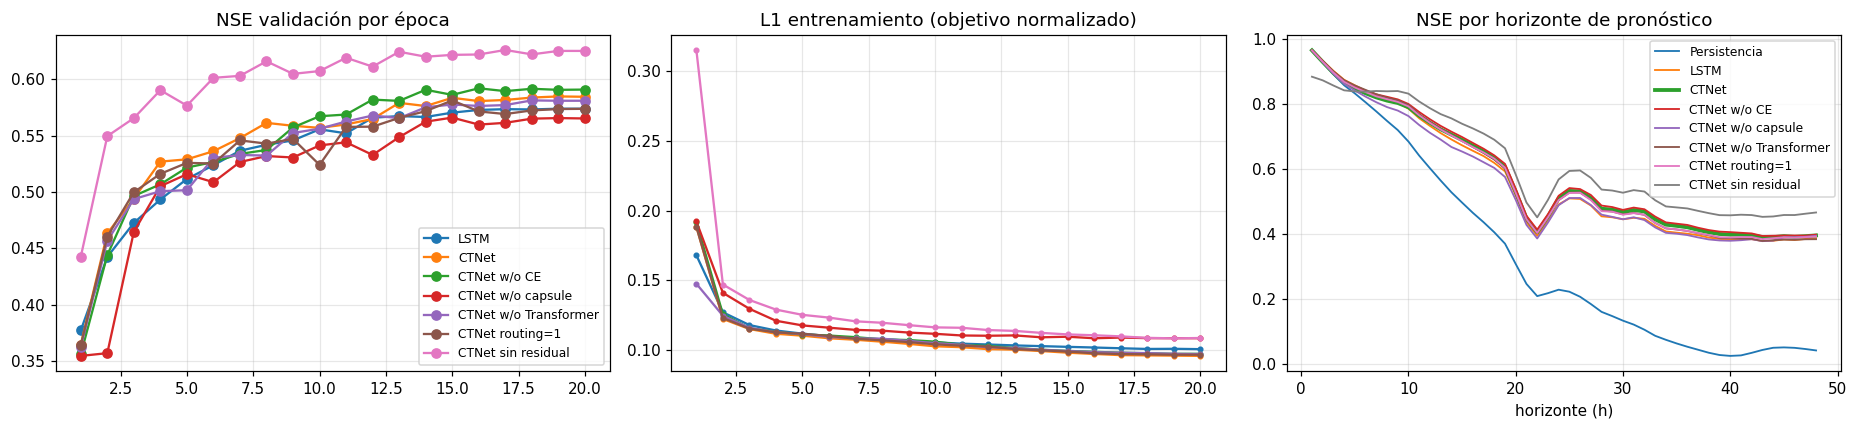

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for k, h in H.items():
    d = pd.DataFrame(h); ax[0].plot(d.epoch, d.val_NSE, marker='o', label=k); ax[1].plot(d.epoch, d.train_L1, marker='.', label=k)
ax[0].set_title('NSE validación por época'); ax[1].set_title('L1 entrenamiento (objetivo normalizado)'); ax[0].legend(fontsize=8)
for k, p in P.items():
    ax[2].plot(np.arange(1, 49), nse_per_horizon(va['y'], p), label=k, lw=2.5 if k == 'CTNet' else 1.2)
ax[2].set_title('NSE por horizonte de pronóstico'); ax[2].set_xlabel('horizonte (h)'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/curvas.png'); plt.show()

## 11. Análisis de errores

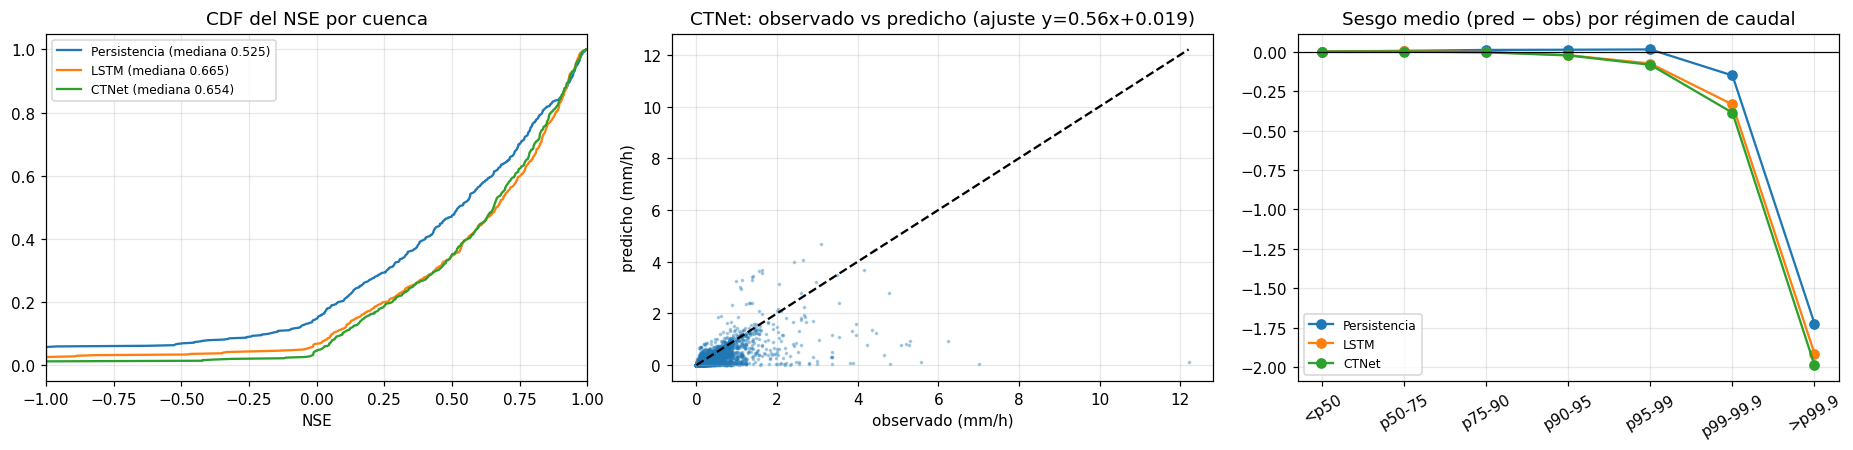

In [16]:
bn = {k: basin_nse(va['y'], P[k], va['basin']) for k in ['Persistencia', 'LSTM', 'CTNet']}
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
for k, s in bn.items():
    v = np.sort(s.clip(-1, 1).values); ax[0].plot(v, np.linspace(0, 1, len(v)), label=f'{k} (mediana {s.median():.3f})')
ax[0].set_xlim(-1, 1); ax[0].set_title('CDF del NSE por cuenca'); ax[0].set_xlabel('NSE'); ax[0].legend(fontsize=8)
yy, pp = va['y'].ravel(), P['CTNet'].ravel(); sel = np.random.default_rng(0).choice(len(yy), 60000, replace=False)
ax[1].scatter(yy[sel], pp[sel], s=2, alpha=.3); mx = yy.max(); ax[1].plot([0, mx], [0, mx], 'k--')
b1, b0 = np.polyfit(yy, pp, 1); ax[1].set_title(f'CTNet: observado vs predicho (ajuste y={b1:.2f}x+{b0:.3f})')
ax[1].set_xlabel('observado (mm/h)'); ax[1].set_ylabel('predicho (mm/h)')
bins = np.percentile(yy, [0, 50, 75, 90, 95, 99, 99.9, 100]); cat = np.digitize(yy, bins[1:-1])
for k in ['Persistencia', 'LSTM', 'CTNet']:
    e = P[k].ravel() - yy; ax[2].plot([np.mean(e[cat == c]) for c in range(len(bins) - 1)], marker='o', label=k)
ax[2].set_xticks(range(len(bins) - 1)); ax[2].set_xticklabels(['<p50', 'p50-75', 'p75-90', 'p90-95', 'p95-99', 'p99-99.9', '>p99.9'], rotation=30)
ax[2].axhline(0, c='k', lw=.8); ax[2].set_title('Sesgo medio (pred − obs) por régimen de caudal'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/errores.png'); plt.show()

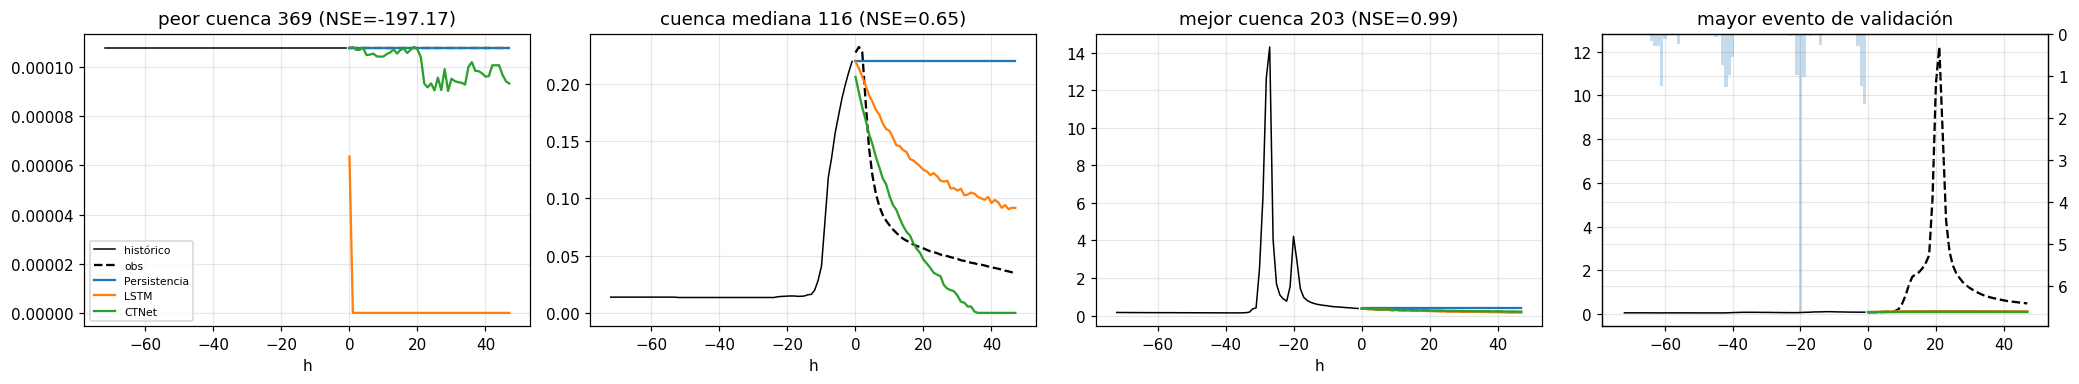

In [17]:
# ejemplos: mejor, mediana y peor cuenca (NSE CTNet) y el mayor evento de validación
s = bn['CTNet'].sort_values()
picks = [('peor cuenca', s.index[0]), ('cuenca mediana', s.index[len(s) // 2]), ('mejor cuenca', s.index[-1])]
fig, ax = plt.subplots(1, 4, figsize=(19, 3.6))
for a, (lbl, b) in zip(ax[:3], picks):
    ids = np.where(va['basin'] == b)[0]; i = ids[np.argmax(va['y'][ids].max(1))]
    a.plot(np.arange(-72, 0), va['X'][i, -72:, FLOW], 'k', lw=1, label='histórico')
    a.plot(va['y'][i], 'k--', label='obs')
    for k in ['Persistencia', 'LSTM', 'CTNet']: a.plot(P[k][i], label=k)
    a.set_title(f'{lbl} {b} (NSE={s[b]:.2f})'); a.set_xlabel('h')
i = int(np.argmax(va['y'].max(1)))
ax[3].plot(np.arange(-72, 0), va['X'][i, -72:, FLOW], 'k', lw=1); ax[3].plot(va['y'][i], 'k--', label='obs')
for k in ['Persistencia', 'LSTM', 'CTNet']: ax[3].plot(P[k][i], label=k)
a3 = ax[3].twinx(); a3.bar(np.arange(-72, 0), va['X'][i, -72:, PRCP], alpha=.25, width=1); a3.invert_yaxis()
ax[3].set_title('mayor evento de validación'); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig('figs/ejemplos.png'); plt.show()

,n,MAE_CTNet,MAE_Persist
lluvia_24h,,,
<0.1,10166,0.0066,0.0078
0.1-5,4904,0.0155,0.0183
5-20,2323,0.0420,0.0516
20-50,659,0.0869,0.1350
>50,90,0.3760,0.7363


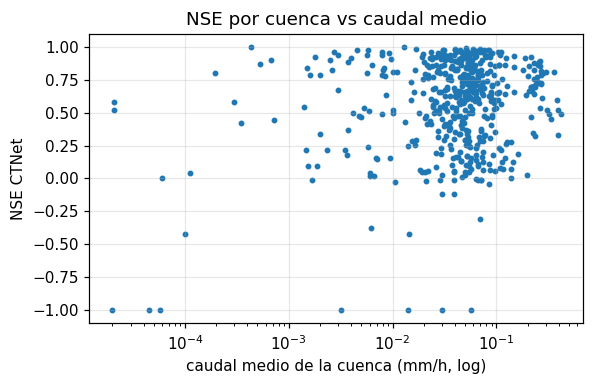

cuencas con NSE<0: 23 de 508


In [18]:
# ¿Cuándo falla? error de CTNet vs lluvia reciente y vs horizonte; relación NSE por cuenca con caudal medio
e_abs = np.abs(P['CTNet'] - va['y']).mean(1)
rain24 = va['X'][:, -24:, PRCP].astype(np.float32).sum(1)
dfe = pd.DataFrame({'lluvia_24h': pd.cut(rain24, [-1, 0.1, 5, 20, 50, 1e4], labels=['<0.1', '0.1-5', '5-20', '20-50', '>50']), 'MAE': e_abs,
                    'MAE_persist': np.abs(P['Persistencia'] - va['y']).mean(1)})
display(dfe.groupby('lluvia_24h', observed=True).agg(n=('MAE', 'size'), MAE_CTNet=('MAE', 'mean'), MAE_Persist=('MAE_persist', 'mean')).round(4))
qm = pd.Series(va['y'].mean(1)).groupby(va['basin']).mean()
fig, ax = plt.subplots(figsize=(5.5, 3.6)); ax.scatter(qm[s.index], s.clip(-1, 1), s=8); ax.set_xscale('log')
ax.set_xlabel('caudal medio de la cuenca (mm/h, log)'); ax.set_ylabel('NSE CTNet'); ax.set_title('NSE por cuenca vs caudal medio')
plt.tight_layout(); plt.savefig('figs/nse_vs_q.png'); plt.show()
print('cuencas con NSE<0:', int((s < 0).sum()), 'de', len(s))

## 12. Interpretabilidad (análogo a las Fig. 10–12 del paper)
* **Cyclic Embedding:** similitud coseno entre horas solares consecutivas y proyección PCA de las 24 filas de $W_{cyc}$.
* **Cápsulas:** coeficientes de acoplamiento $c_{ij}$ promedio (día de la ventana → cápsula alta) y norma media de cada cápsula alta (probabilidad de "activación").

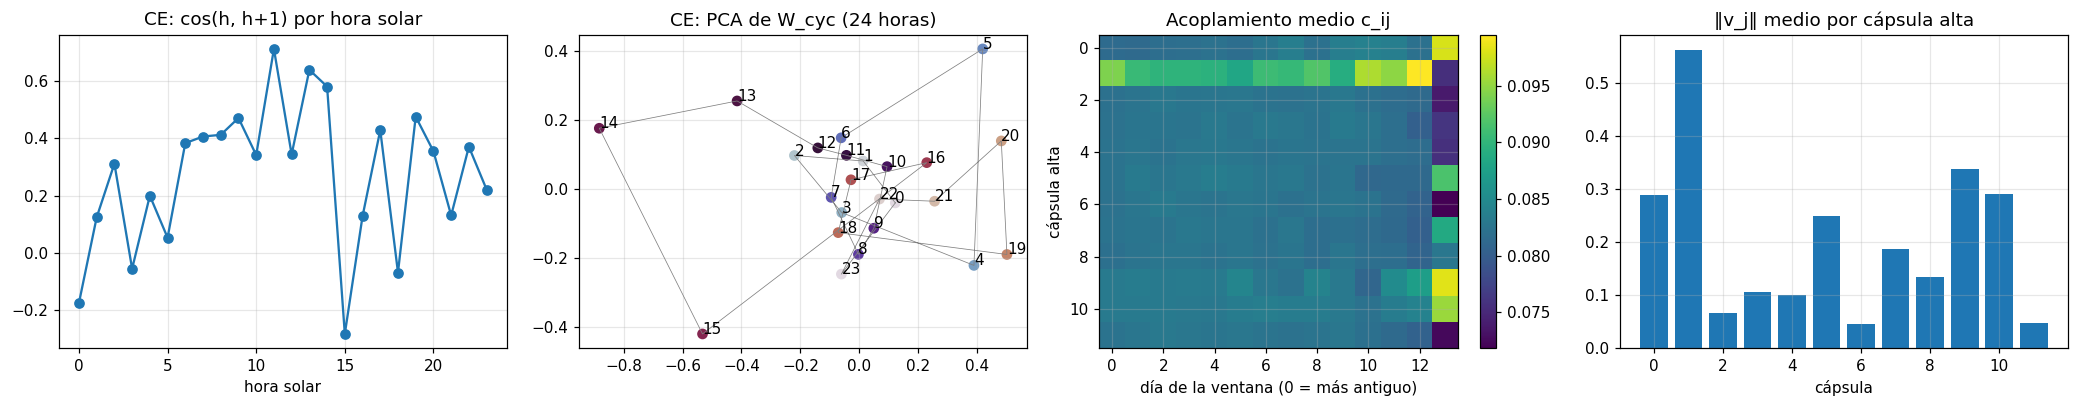

In [19]:
W = ctnet.emb.cyc.weight.detach().cpu().numpy()
Wn = W / np.linalg.norm(W, axis=1, keepdims=True)
sim = (Wn * np.roll(Wn, -1, 0)).sum(1)
U, S, Vt = np.linalg.svd(W - W.mean(0)); pc = U[:, :2] * S[:2]
with torch.no_grad():
    ctnet.eval(); b = next(batches(Tva, 1024, False))
    oc = ctnet.route(ctnet.prim(ctnet.emb(b['X'].to(DEVICE), b['idx'].to(DEVICE))))
    c = ctnet.route.last_c.cpu().numpy()                    # [B, 14*8, 12]
cday = c.reshape(c.shape[0], 14, 8, 12).mean((0, 2))        # día x cápsula alta
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
ax[0].plot(sim, marker='o'); ax[0].set_title('CE: cos(h, h+1) por hora solar'); ax[0].set_xlabel('hora solar')
ax[1].scatter(pc[:, 0], pc[:, 1], c=np.arange(24), cmap='twilight'); [ax[1].annotate(str(h), pc[h]) for h in range(24)]
ax[1].plot(*np.vstack([pc, pc[:1]]).T, lw=.5, c='gray'); ax[1].set_title('CE: PCA de W_cyc (24 horas)')
im = ax[2].imshow(cday.T, aspect='auto', cmap='viridis'); ax[2].set_xlabel('día de la ventana (0 = más antiguo)'); ax[2].set_ylabel('cápsula alta')
ax[2].set_title('Acoplamiento medio c_ij'); plt.colorbar(im, ax=ax[2])
ax[3].bar(range(12), oc.norm(dim=-1).mean(0).cpu().numpy()); ax[3].set_title('‖v_j‖ medio por cápsula alta'); ax[3].set_xlabel('cápsula')
plt.tight_layout(); plt.savefig('figs/interpretabilidad.png'); plt.show()

## 13. Predicciones y evaluación en test
`test.h5` contiene `X [27 983, 336, 12]` y `basin_id`. Se aplica el mismo preprocesamiento (presión → kPa, z-score con estadísticas de *train*, fase solar)
y se exporta **`predicciones_test.csv`** con el mismo formato que `test_targets.csv`: `Id` (índice de fila, base 0) y `q_01 … q_48` en mm/h.
También se guarda `predicciones_test.npy` `[N, 48]`.

Como el curso publicó `test_targets.csv`, se evalúan **todos los modelos en test**: datos que no se usaron ni para entrenar ni para elegir la época.
Para saber si las diferencias entre modelos son reales, se calcula un **intervalo de confianza del 95 % por *bootstrap* de cuencas** (1 000 remuestreos de las 508 cuencas)
para la diferencia de NSE de cada modelo respecto de CTNet.

In [20]:
def predict_h5(model, path, chunk=4096):
    preds = []
    with h5py.File(path, 'r') as f:
        key = 'X' if 'X' in f else 'x'
        for s in range(0, f[key].shape[0], chunk):
            X = f[key][s:s + chunk].astype(np.float32); X[..., PRES] /= 1000.
            d = {'X': X, 'y': np.zeros((len(X), 48), np.float32), 'idx': solar_phase_idx(X)}
            preds.append(predict(model, to_tensors(d)))
        basins = f['basin_id'][:]
        qlast = f[key][:, -1, FLOW]
    return np.concatenate(preds), basins, qlast

def save_preds(pred, prefix):
    np.save(f'{prefix}.npy', pred.astype(np.float32))
    df = pd.DataFrame(pred, columns=[f'q_{i+1:02d}' for i in range(48)])
    df.insert(0, 'Id', np.arange(len(pred)))               # mismo formato que test_targets.csv
    df.to_csv(f'{prefix}.csv', index=False, float_format='%.9g'); return df

assert os.path.exists(H5_TEST), f'No se encontró {H5_TEST}: copie test.h5 en la carpeta del notebook'
pt, bt, ql = predict_h5(ctnet, H5_TEST)
df_test = save_preds(pt, 'predicciones_test')
print('predicciones_test.csv:', df_test.shape, '| columnas:', list(df_test.columns[:3]), '...', df_test.columns[-1])
display(df_test.head())

predicciones_test.csv: (27983, 49) | columnas: ['Id', 'q_01', 'q_02'] ... q_48


,Id,q_01,q_02,q_03,q_04,q_05,q_06,q_07,q_08,q_09,...,q_39,q_40,q_41,q_42,q_43,q_44,q_45,q_46,q_47,q_48
0,0,0.179739,0.178039,0.176409,0.174825,0.173307,0.171947,0.170493,0.169013,0.167695,...,0.140470,0.140136,0.139471,0.138867,0.138047,0.137699,0.137418,0.136386,0.135923,0.135500
1,1,0.018765,0.018798,0.018450,0.018478,0.018544,0.018461,0.017897,0.018259,0.018083,...,0.018871,0.018823,0.018758,0.018259,0.019098,0.018206,0.019421,0.018437,0.018859,0.018048
2,2,0.002648,0.002648,0.002645,0.002645,0.002645,0.002641,0.002640,0.002640,0.002639,...,0.002621,0.002620,0.002619,0.002618,0.002623,0.002622,0.002622,0.002617,0.002614,0.002612
3,3,0.017826,0.017726,0.017605,0.017549,0.017528,0.017417,0.016949,0.017081,0.016978,...,0.016808,0.016696,0.016913,0.016498,0.017084,0.016475,0.017278,0.016529,0.016811,0.016070
4,4,0.000976,0.000977,0.000976,0.000976,0.000976,0.000974,0.000974,0.000974,0.000973,...,0.000967,0.000966,0.000965,0.000965,0.000969,0.000969,0.000969,0.000966,0.000963,0.000962


In [21]:
# Evaluación en test con los valores reales (test_targets.csv)
assert TEST_TARGETS, 'Copie test_targets.csv en la carpeta del notebook'
yt_df = pd.read_csv(TEST_TARGETS).sort_values('Id')
assert (yt_df['Id'].values == np.arange(len(pt))).all()
yt = yt_df[[f'q_{i+1:02d}' for i in range(48)]].values.astype(np.float32)

PT = {'Persistencia': np.repeat(ql[:, None], 48, 1).astype(np.float32), 'CTNet': pt}
for k, m in MODELS.items():
    if k != 'CTNet': PT[k] = predict_h5(m, H5_TEST)[0]
ORDER = [k for k in ['Persistencia', 'LSTM', 'CTNet', 'CTNet w/o CE', 'CTNet w/o capsule', 'CTNet w/o Transformer',
                     'CTNet routing=1', 'CTNet sin residual'] if k in PT]

# Bootstrap por cuencas: IC 95 % del NSE y de la diferencia de NSE vs CTNet
ub, inv = np.unique(bt, return_inverse=True); nb_ = len(ub)
def basin_sums(p):
    e2 = ((yt - p) ** 2).sum(1)
    return np.bincount(inv, e2, nb_)
S_y  = np.bincount(inv, yt.sum(1), nb_); S_y2 = np.bincount(inv, (yt.astype(np.float64) ** 2).sum(1), nb_)
S_n  = np.bincount(inv, np.full(len(yt), 48.), nb_)
SSE  = {k: basin_sums(PT[k]) for k in ORDER}
W = np.random.default_rng(0).multinomial(nb_, np.full(nb_, 1 / nb_), size=1000).astype(np.float64)   # pesos de remuestreo
den = W @ S_y2 - (W @ S_y) ** 2 / (W @ S_n)
NSE_bs = {k: 1 - (W @ SSE[k]) / den for k in ORDER}

res_test = pd.DataFrame({k: full_report(yt, PT[k], bt) for k in ORDER}).T
res_test['NSE IC95%'] = [f"[{np.percentile(NSE_bs[k], 2.5):.3f}, {np.percentile(NSE_bs[k], 97.5):.3f}]" for k in ORDER]
d = {k: NSE_bs[k] - NSE_bs['CTNet'] for k in ORDER}
res_test['ΔNSE vs CTNet'] = [res_test.loc[k, 'NSE'] - res_test.loc['CTNet', 'NSE'] for k in ORDER]
res_test['IC95% Δ'] = [f"[{np.percentile(d[k], 2.5):+.3f}, {np.percentile(d[k], 97.5):+.3f}]" for k in ORDER]
res_test['¿significativo?'] = ['—' if k == 'CTNet' else ('sí' if np.percentile(d[k], 2.5) > 0 or np.percentile(d[k], 97.5) < 0 else 'no') for k in ORDER]
res_test.to_csv('figs/resultados_test.csv')
display(res_test.drop(columns=['NSE_h1']).round(4))

,MAE,RMSE,NSE,CC,WI,NSE_cuenca_mediana,MAE_picos(p99),err_rel_pico_%,NSE_h24,NSE_h48,NSE IC95%,ΔNSE vs CTNet,IC95% Δ,¿significativo?
Persistencia,0.0246,0.1188,0.4956,0.7389,0.8504,0.4916,0.6238,-79.2408,0.4907,0.1890,"[0.439, 0.556]",-0.1115,"[-0.149, -0.078]",sí
LSTM,0.0189,0.1041,0.6130,0.7881,0.8558,0.6271,0.5179,-78.8443,0.6250,0.3714,"[0.562, 0.667]",0.0058,"[+0.000, +0.011]",sí
CTNet,0.0190,0.1048,0.6071,0.7856,0.8512,0.6316,0.5240,-78.4695,0.6222,0.3597,"[0.555, 0.660]",0.0000,"[+0.000, +0.000]",—
CTNet w/o CE,0.0191,0.1053,0.6036,0.7831,0.8496,0.6271,0.5291,-78.7438,0.6175,0.3595,"[0.551, 0.656]",-0.0035,"[-0.008, +0.001]",no
CTNet w/o capsule,0.0189,0.1054,0.6032,0.7812,0.8526,0.6332,0.5288,-79.6041,0.6177,0.3637,"[0.552, 0.656]",-0.0039,"[-0.010, +0.002]",no
CTNet w/o Transformer,0.0195,0.1054,0.6028,0.7813,0.8502,0.6110,0.5267,-77.8692,0.6168,0.3542,"[0.551, 0.655]",-0.0044,"[-0.009, -0.001]",sí
CTNet routing=1,0.0194,0.1047,0.6080,0.7839,0.8543,0.6190,0.5260,-78.1138,0.6252,0.3552,"[0.556, 0.660]",0.0009,"[-0.003, +0.004]",no
CTNet sin residual,0.0204,0.1035,0.6173,0.7886,0.8605,0.6099,0.5061,-76.5753,0.6360,0.3776,"[0.566, 0.670]",0.0102,"[+0.005, +0.016]",sí


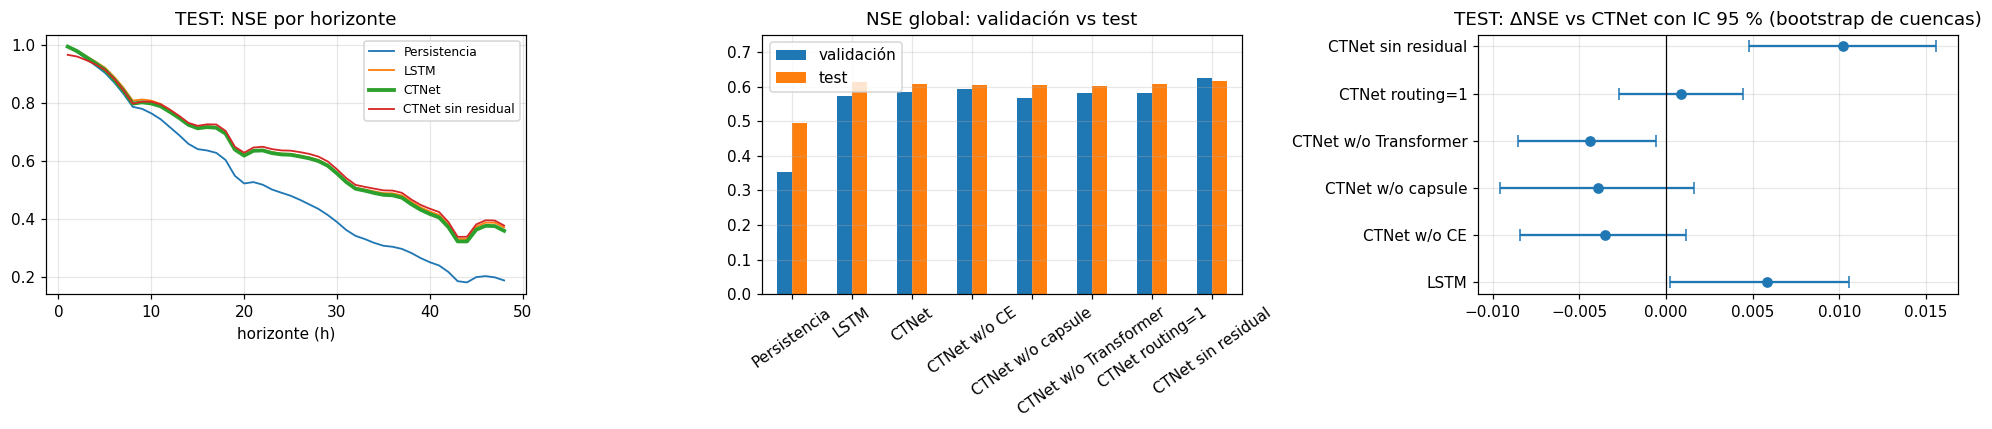

CTNet sin residual: NSE test 0.617 (CTNet 0.607; ΔNSE +0.010, IC95% [+0.005, +0.016], significativo: sí) | NSE h1 0.965 vs 0.993 | NSE h48 0.378 vs 0.360


In [22]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for k in ['Persistencia', 'LSTM', 'CTNet', 'CTNet sin residual']:
    if k in PT: ax[0].plot(np.arange(1, 49), nse_per_horizon(yt, PT[k]), label=k, lw=2.5 if k == 'CTNet' else 1.2)
ax[0].set_title('TEST: NSE por horizonte'); ax[0].set_xlabel('horizonte (h)'); ax[0].legend(fontsize=8)
comp = pd.DataFrame({'validación': res['NSE'], 'test': res_test['NSE']}).reindex(ORDER)
comp.plot.bar(ax=ax[1], rot=35); ax[1].set_title('NSE global: validación vs test'); ax[1].set_ylim(0, 0.75)
ks = [k for k in ORDER if k not in ('CTNet', 'Persistencia')]
lo = [res_test.loc[k, 'ΔNSE vs CTNet'] - np.percentile(d[k], 2.5) for k in ks]
hi = [np.percentile(d[k], 97.5) - res_test.loc[k, 'ΔNSE vs CTNet'] for k in ks]
ax[2].errorbar(res_test.loc[ks, 'ΔNSE vs CTNet'], range(len(ks)), xerr=[lo, hi], fmt='o', capsize=4)
ax[2].axvline(0, c='k', lw=.8); ax[2].set_yticks(range(len(ks))); ax[2].set_yticklabels(ks)
ax[2].set_title('TEST: ΔNSE vs CTNet con IC 95 % (bootstrap de cuencas)')
plt.tight_layout(); plt.savefig('figs/test.png'); plt.show()

# Resumen automático de la ablación del objetivo residual (se cita en las conclusiones)
if 'CTNet sin residual' in PT:
    r = res_test.loc['CTNet sin residual']
    print(f"CTNet sin residual: NSE test {r['NSE']:.3f} (CTNet {res_test.loc['CTNet','NSE']:.3f}; ΔNSE {r['ΔNSE vs CTNet']:+.3f}, IC95% {r['IC95% Δ']}, "
          f"significativo: {r['¿significativo?']}) | NSE h1 {r['NSE_h1']:.3f} vs {res_test.loc['CTNet','NSE_h1']:.3f} | "
          f"NSE h48 {r['NSE_h48']:.3f} vs {res_test.loc['CTNet','NSE_h48']:.3f}")

## 14. Conclusiones, limitaciones y diferencias con el paper

> Los resultados de referencia son los de **test** (27 983 ventanas que no se usaron ni para entrenar ni para elegir la época). Validación se usó para el *early stopping*, por eso sus números son algo optimistas.

### Resultados principales (test)

| Modelo | NSE | IC 95 % | MAE (mm/h) | NSE mediano por cuenca | NSE 24 h | NSE 48 h | Parámetros |
|---|---|---|---|---|---|---|---|
| Persistencia | 0.496 | [0.439, 0.556] | 0.0246 | 0.492 | 0.491 | 0.189 | 0 |
| LSTM | **0.613** | [0.562, 0.667] | **0.0189** | 0.627 | 0.625 | **0.371** | 23 k |
| CTNet | 0.607 | [0.555, 0.660] | 0.0190 | **0.632** | 0.622 | 0.360 | 482 k |

**1. CTNet le gana claramente a la persistencia, pero no al LSTM.** Frente a la persistencia, el NSE sube de 0.50 a 0.61. Frente al LSTM, CTNet queda **ligeramente por debajo** en NSE global: ΔNSE = −0.006, con un IC 95 % de la diferencia de [−0.011, 0.000] según el *bootstrap* de cuencas. La diferencia es pequeña y está en el límite de ser significativa. En el NSE mediano por cuenca CTNet queda apenas arriba (0.632 vs 0.627). En resumen, **los dos modelos rinden prácticamente igual**, y el LSTM lo logra con 20 veces menos parámetros. No reproducimos la superioridad que el paper reporta frente al LSTM. Nuestra lectura: con 336 h horarias y 508 cuencas, la dificultad no está en la arquitectura sino en predecir los eventos de lluvia, y un LSTM pequeño ya captura bien la recesión del caudal.

**2. El aporte del modelo está en los horizontes largos y en los eventos de lluvia.** En la primera hora todos los modelos tienen NSE ≈ 0.99, porque el caudal casi no cambia en una hora. A las 48 h CTNet llega a 0.36, mientras que la persistencia cae a 0.19. En validación, con más de 50 mm de lluvia en 24 h, CTNet tiene la mitad del error de la persistencia. La red aprende la respuesta de la cuenca a la lluvia.

**3. Validación y test no cuentan la misma historia, y eso es una lección.** En validación CTNet superaba al LSTM (0.585 vs 0.574) y la ablación parecía mostrar efectos claros. En test esas diferencias desaparecen o se invierten. Con una sola semilla y una validación usada para elegir la época, diferencias de ±0.01 en NSE no son confiables. Por eso agregamos los intervalos de confianza.

### Ablación (test, ΔNSE respecto de CTNet con IC 95 %)

| Variante | ΔNSE | IC 95 % | ¿Significativo? | Lectura |
|---|---|---|---|---|
| w/o CE | −0.004 | [−0.008, +0.001] | no | El cyclic embedding (hora solar, D = 24) no aporta de forma medible |
| w/o capsule | −0.004 | [−0.010, +0.002] | no | Sin cápsulas el resultado casi no cambia |
| w/o Transformer | −0.004 | [−0.009, −0.001] | sí (pequeño) | Única rama cuya eliminación empeora de forma consistente, aunque poco |
| routing = 1 | +0.001 | [−0.003, +0.004] | no | El routing dinámico de 3 iteraciones no mejora sobre acoplamientos uniformes |
| sin objetivo residual | ver celda 14.1 | | | Mide cuánto aporta nuestra adaptación frente a la del paper |

* **Ningún componente propio de CTNet (CE, cápsulas, routing) tiene un efecto significativo en test.** El paper reporta caídas de 2 a 11 % de NSE al quitar el CE o las cápsulas. Nosotros no lo reproducimos. Hay tres razones probables:
  1. El CE original codifica el **ciclo anual**, y sin fechas solo pudimos usar el ciclo diario. Ese ciclo ya está implícito en la radiación de onda corta, y el caudal casi no lo tiene. El PCA de $W_{cyc}$ no forma un círculo, lo que confirma que no aprendió estructura cíclica útil.
  2. Las 12 cápsulas del paper se justifican por los 12 meses del año, una motivación que no aplica a ventanas de 14 días. En la interpretabilidad, el acoplamiento se concentra en el último día y varias cápsulas altas tienen norma casi cero, es decir, son redundantes.
  3. El paper trabaja con **una sola cuenca** y datos diarios, mientras que aquí hay 508 cuencas con datos horarios.
* La rama **Transformer** es la única cuya eliminación empeora de forma consistente, aunque el efecto es pequeño (−0.004).

### Análisis de errores

* **Todos los modelos subestiman los picos**: en test el pico predicho sale ~78 % por debajo del real. Hay dos causas. La pérdida L1 empuja hacia la mediana, y los picos son menos del 1 % de los datos. Además, el modelo no conoce la lluvia futura, porque `y_aux` no está disponible en test, así que no puede anticipar crecidas causadas por lluvia que aún no cae. Es el principal error y el más importante en hidrología.
* En caudales normales (bajo el p95) el sesgo es prácticamente cero. El problema se concentra en los eventos extremos.
* 23 de 508 cuencas tienen NSE < 0 en validación. Suelen ser cuencas con caudal muy bajo o casi constante, donde el NSE es inestable.

### Limitaciones

* Usamos 54 000 ventanas de entrenamiento (~21 % del total) y **una sola semilla** por modelo.
* No hay fechas en los datos, así que no pudimos usar el ciclo anual del CE original.
* No usamos `y_aux` como objetivo auxiliar. Según `metadata.json` sirve solo para supervisión durante el entrenamiento, no como entrada en la inferencia.
* La pérdida L1 favorece la mediana y perjudica los picos.

### Qué mejoraríamos

1. Usar una pérdida que castigue los picos (MSE, Huber o una L1 ponderada por caudal) y evaluar con métricas de eventos.
2. Entrenar con todo el *train* y con 3 a 5 semillas para confirmar la ablación.
3. Usar `y_aux` como objetivo auxiliar (aprendizaje multitarea).
4. Probar el CE con un proxy del ciclo anual, por ejemplo la duración del día calculada desde la radiación.

**En resumen:** implementamos CTNet completo desde cero (482 k parámetros, como el paper) y lo adaptamos a pronóstico horario de 48 h en 508 cuencas. Supera claramente a la persistencia, pero **empata con un LSTM 20 veces más pequeño**. Los componentes distintivos del paper (cápsulas, routing y cyclic embedding) no muestran un aporte significativo en test, en parte porque su motivación (el ciclo anual y los 12 meses) no se puede trasladar a ventanas horarias sin fechas. La tarea pendiente es predecir mejor los picos de crecida.


### 14.1 Efecto del objetivo residual (ablación de nuestra adaptación)
La siguiente celda resume el resultado a partir de la tabla de test, para que la conclusión no dependa de números escritos a mano.

In [23]:
if 'CTNet sin residual' in res_test.index:
    r, c = res_test.loc['CTNet sin residual'], res_test.loc['CTNet']
    lo, hi = np.percentile(d['CTNet sin residual'], [2.5, 97.5])
    print(f"CTNet sin residual: NSE test {r['NSE']:.3f} vs CTNet {c['NSE']:.3f}  (ΔNSE {r['ΔNSE vs CTNet']:+.3f}, IC95% [{lo:+.3f}, {hi:+.3f}])")
    print(f"  NSE 1 h: {r['NSE_h1']:.3f} vs {c['NSE_h1']:.3f} | NSE 48 h: {r['NSE_h48']:.3f} vs {c['NSE_h48']:.3f} | MAE picos: {r['MAE_picos(p99)']:.3f} vs {c['MAE_picos(p99)']:.3f}")
    if hi < 0:
        print('→ Conclusión: el objetivo residual mejora de forma significativa. Gran parte del buen desempeño se debe a esta adaptación: '
              'al predecir la corrección sobre el último caudal, la red no tiene que reaprender el nivel de cada cuenca (sobre todo en las primeras horas).')
    elif lo > 0:
        print('→ Conclusión: predecir el caudal directamente (como el paper) es mejor que el objetivo residual en este dataset.')
    else:
        print('→ Conclusión: no hay diferencia significativa entre predecir el residuo o el caudal directo.')
else:
    print('Ejecute la ablación "CTNet sin residual" (sección 9).')

CTNet sin residual: NSE test 0.617 vs CTNet 0.607  (ΔNSE +0.010, IC95% [+0.005, +0.016])
  NSE 1 h: 0.965 vs 0.993 | NSE 48 h: 0.378 vs 0.360 | MAE picos: 0.506 vs 0.524
→ Conclusión: predecir el caudal directamente (como el paper) es mejor que el objetivo residual en este dataset.
